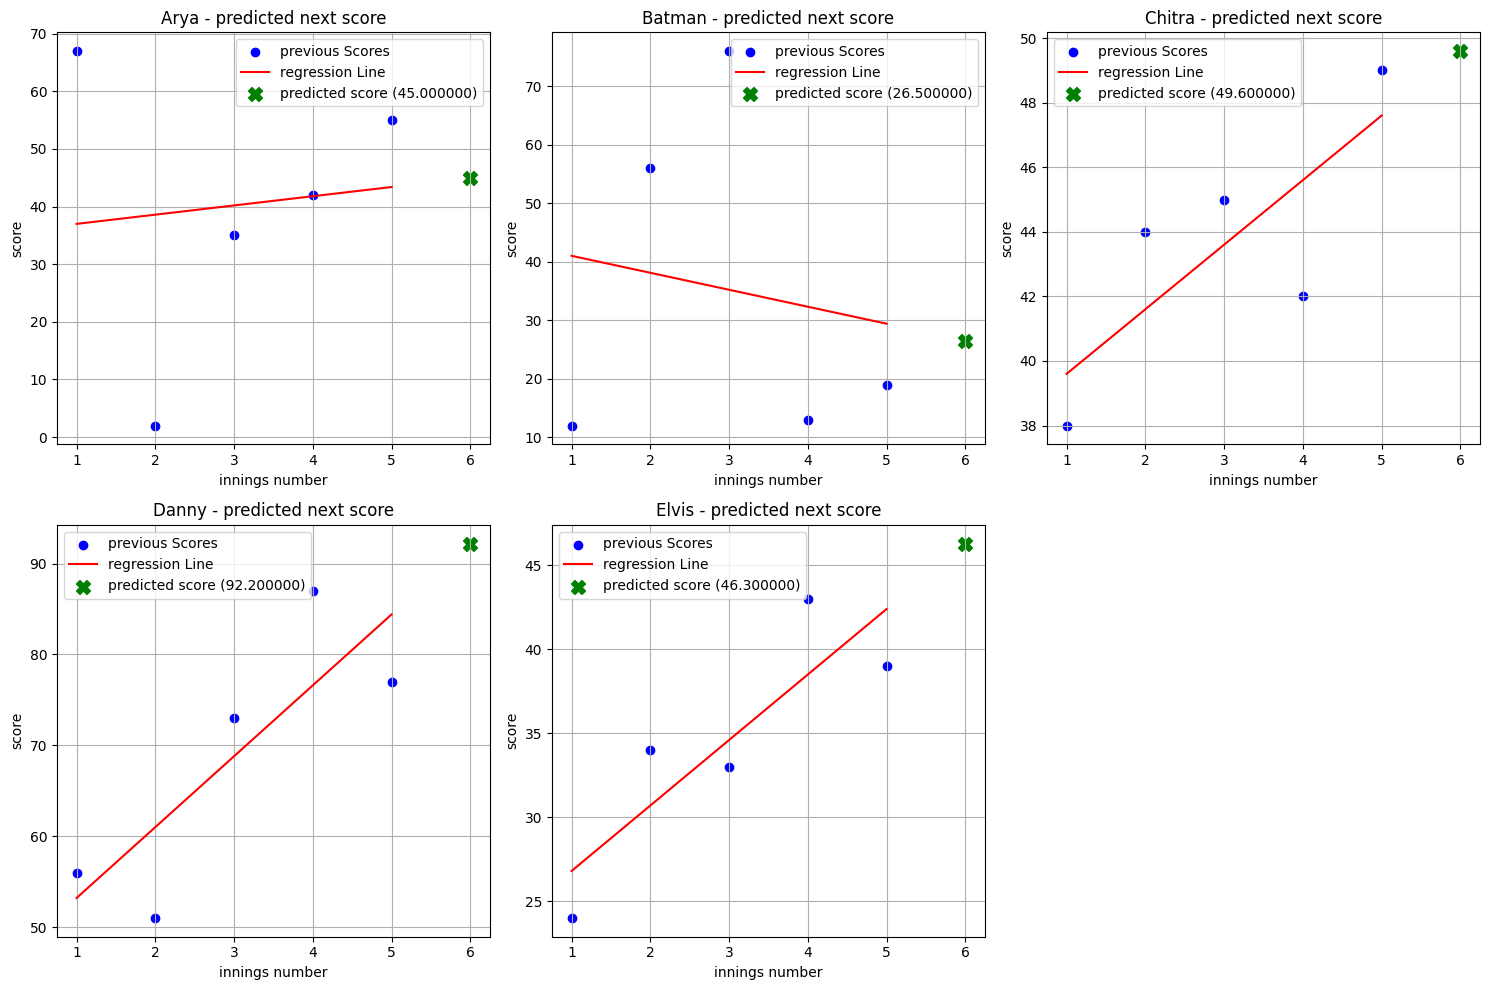

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

#batsmen names as strings and their scores
batsmen_names = ['arya', 'batman', 'chitra', 'danny', 'elvis']
scores = {
    'arya': np.array([67, 2, 35, 42, 55]),
    'batman': np.array([12, 56, 76, 13, 19]),
    'chitra': np.array([38, 44, 45, 42, 49]),
    'danny': np.array([56, 51, 73, 87, 77]),
    'elvis': np.array([24, 34, 33, 43, 39])
}
#note- complete randoom input is used as the data.
#mak plot to predict score of each batsmen in next innings based on the prev record.

plt.figure(figsize=(15, 10))

for i, name in enumerate(batsmen_names):
    current_scores = scores[name]
    innings = np.arange(1, len(current_scores) + 1).reshape(-1, 1)

    #create and train the linear regression model
    model = LinearRegression()
    model.fit(innings, current_scores)

    #Predict the score for the next innings i.e.---->>>(innings + 1)
    next_innings = np.array([[len(current_scores) + 1]])
    predicted_score = model.predict(next_innings)[0]

    #plotting of the graph
    plt.subplot(2, 3, i + 1) # arrrange plots in a 2 x 3 grid
    plt.scatter(innings, current_scores, color='blue', label='previous Scores')
    plt.plot(innings, model.predict(innings), color='red', label='regression Line')
    plt.scatter(next_innings, predicted_score, color='green', marker='X', s=100, label=f'predicted score ({predicted_score:f})')

    #labels for the plots
    plt.title(f'{name.capitalize()} - predicted next score')
    plt.xlabel('innings number')
    plt.ylabel('score')
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()

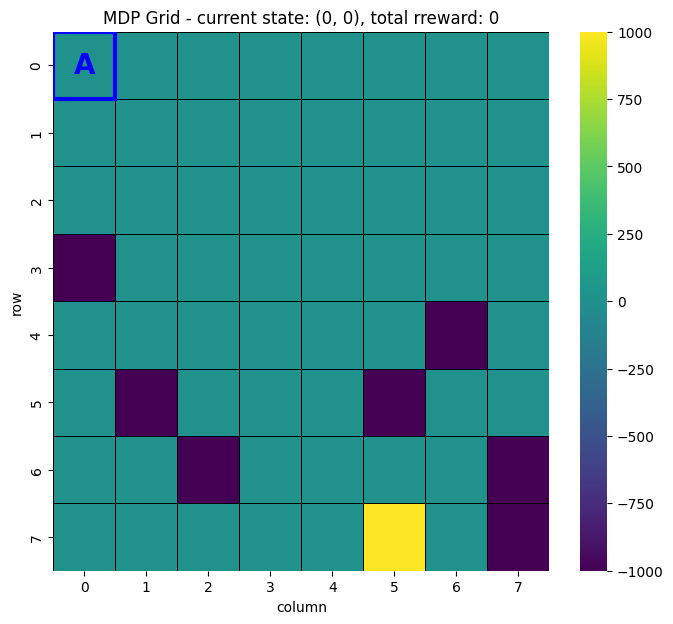


Agent is at: (0, 0)
Total reward accumulated: 0
Enter action (up, down, left, right): up
Moved UP. New state: (0, 0). Reward from this move: -10.


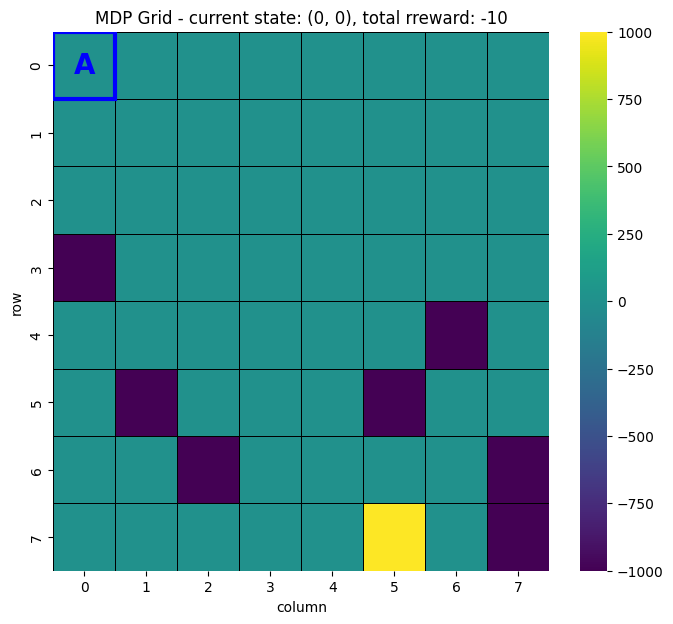


Agent is at: (0, 0)
Total reward accumulated: -10
Enter action (up, down, left, right): down
Moved DOWN. New state: (1, 0). Reward from this move: 0.0.


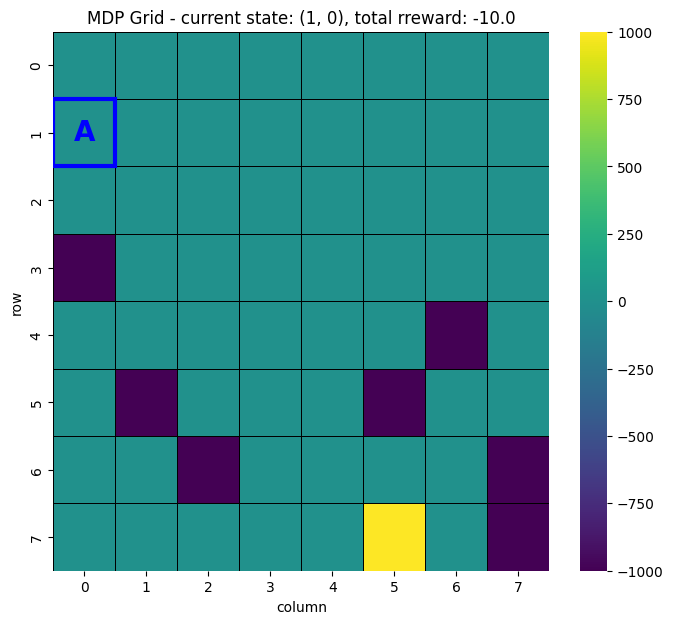


Agent is at: (1, 0)
Total reward accumulated: -10.0
Enter action (up, down, left, right): right
Moved RIGHT. New state: (1, 1). Reward from this move: 0.0.


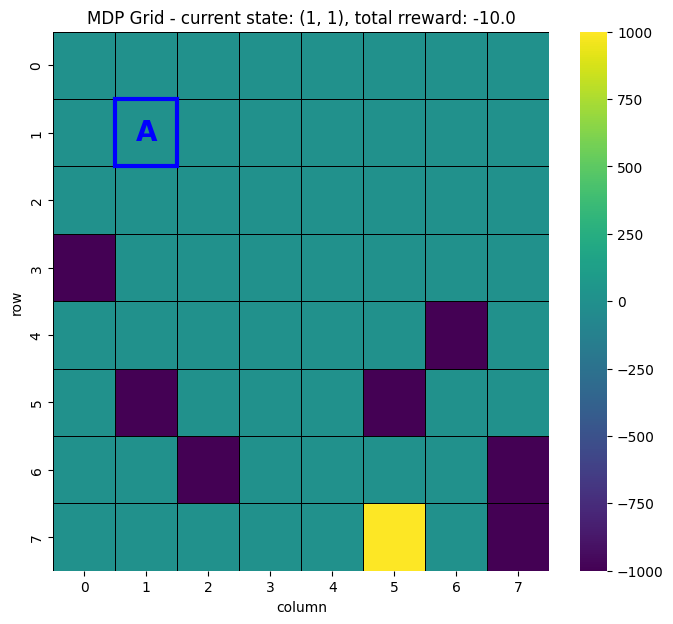


Agent is at: (1, 1)
Total reward accumulated: -10.0
Enter action (up, down, left, right): right
Moved RIGHT. New state: (1, 2). Reward from this move: 0.0.


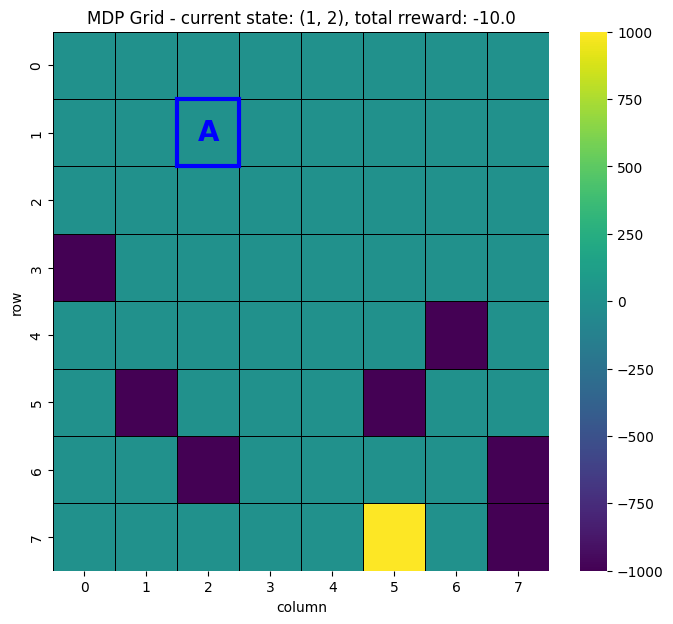


Agent is at: (1, 2)
Total reward accumulated: -10.0
Enter action (up, down, left, right): down
Moved DOWN. New state: (2, 2). Reward from this move: 0.0.


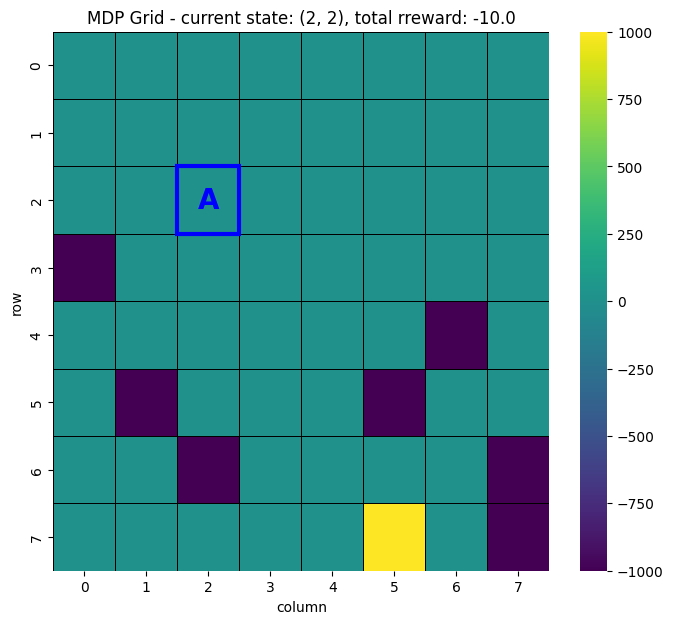


Agent is at: (2, 2)
Total reward accumulated: -10.0
Enter action (up, down, left, right): down
Moved DOWN. New state: (3, 2). Reward from this move: 0.0.


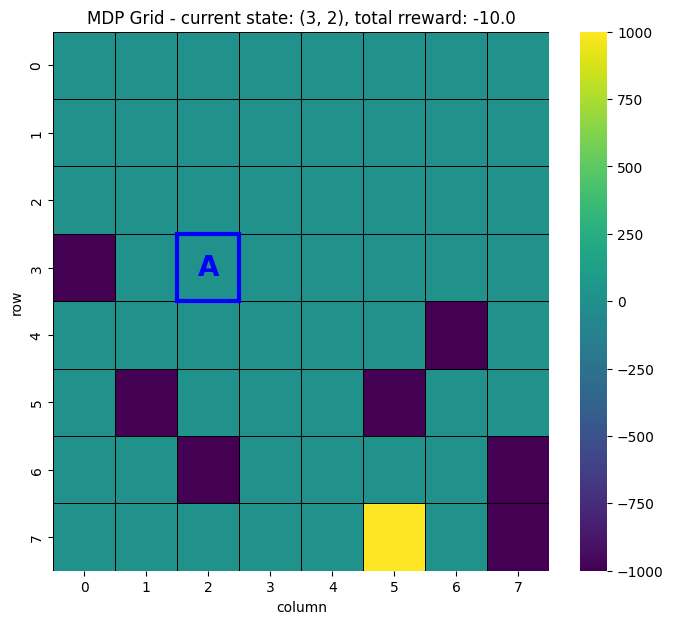


Agent is at: (3, 2)
Total reward accumulated: -10.0
Enter action (up, down, left, right): down
Moved DOWN. New state: (4, 2). Reward from this move: 0.0.


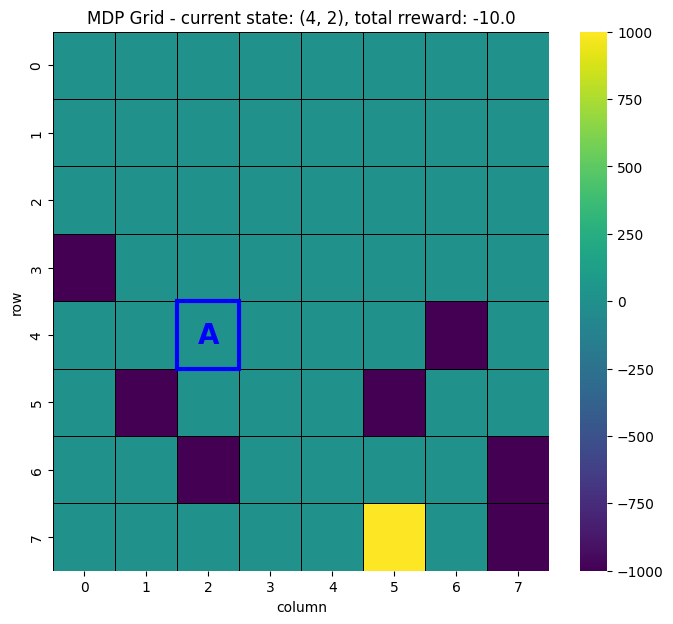


Agent is at: (4, 2)
Total reward accumulated: -10.0
Enter action (up, down, left, right): right
Moved RIGHT. New state: (4, 3). Reward from this move: 0.0.


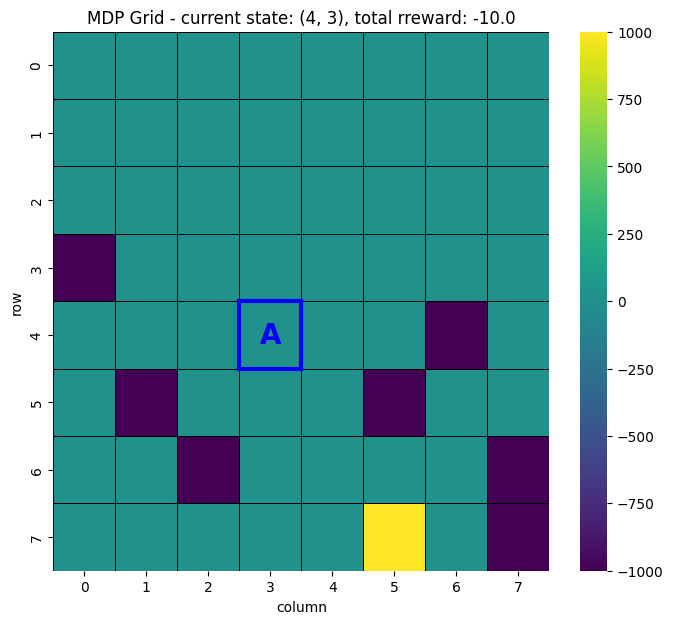


Agent is at: (4, 3)
Total reward accumulated: -10.0
Enter action (up, down, left, right): down
Moved DOWN. New state: (5, 3). Reward from this move: 0.0.


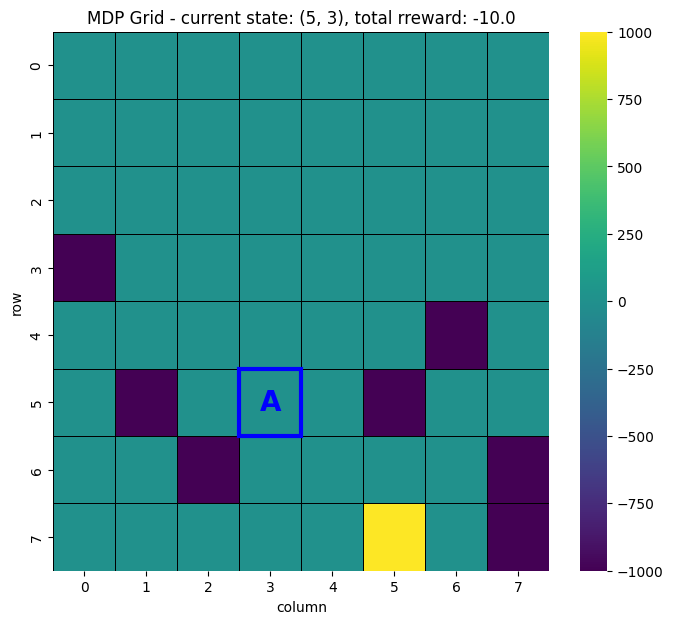


Agent is at: (5, 3)
Total reward accumulated: -10.0
Enter action (up, down, left, right): right
Moved RIGHT. New state: (5, 4). Reward from this move: 0.0.


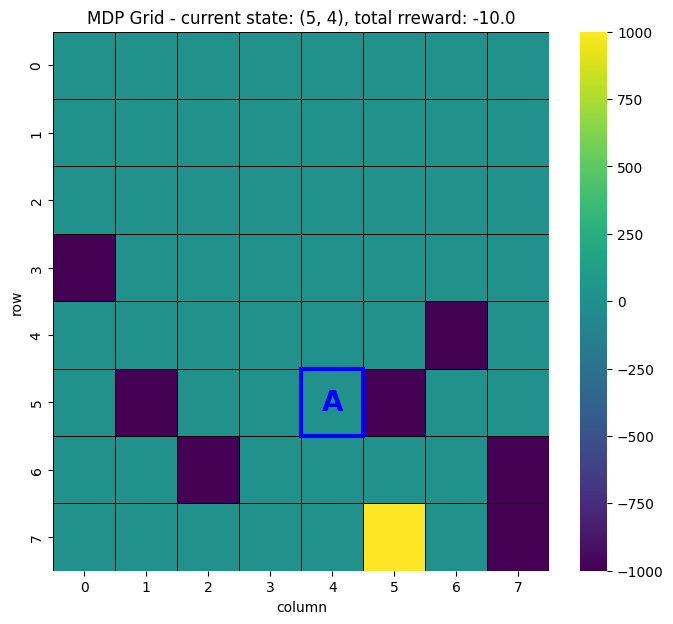


Agent is at: (5, 4)
Total reward accumulated: -10.0
Enter action (up, down, left, right): down
Moved DOWN. New state: (6, 4). Reward from this move: 0.0.


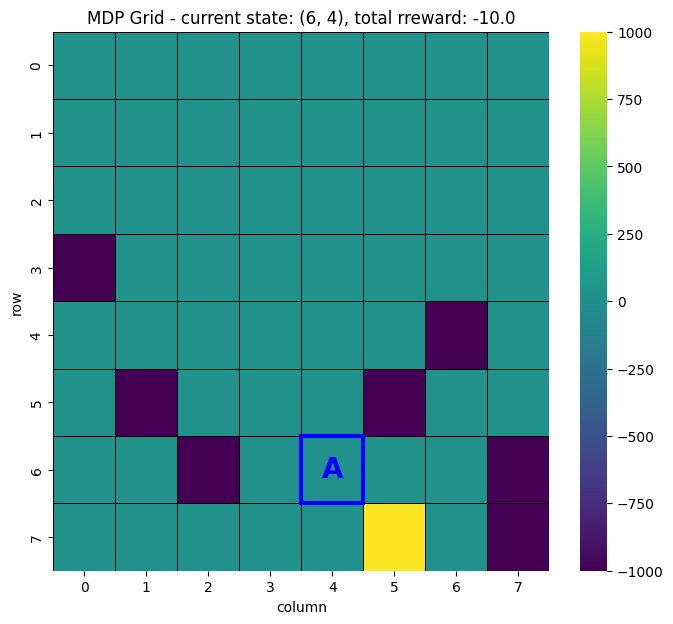


Agent is at: (6, 4)
Total reward accumulated: -10.0
Enter action (up, down, left, right): down
Moved DOWN. New state: (7, 4). Reward from this move: 0.0.


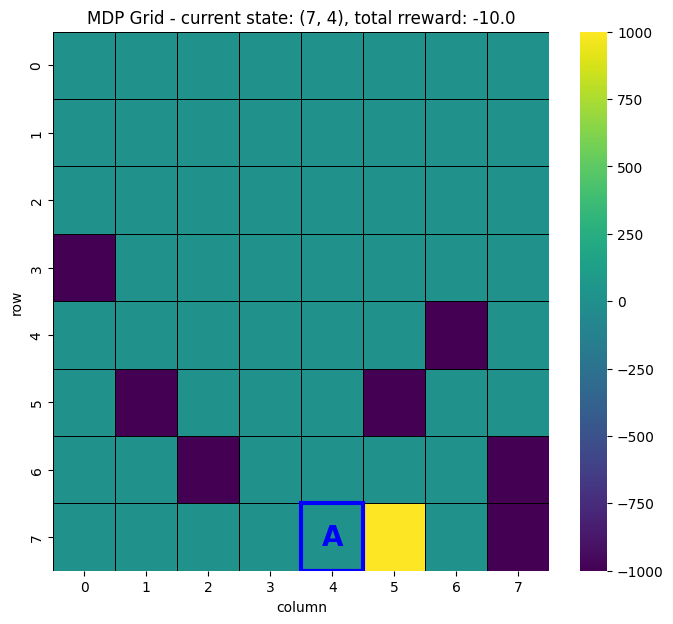


Agent is at: (7, 4)
Total reward accumulated: -10.0
Enter action (up, down, left, right): left
Moved LEFT. New state: (7, 3). Reward from this move: 0.0.


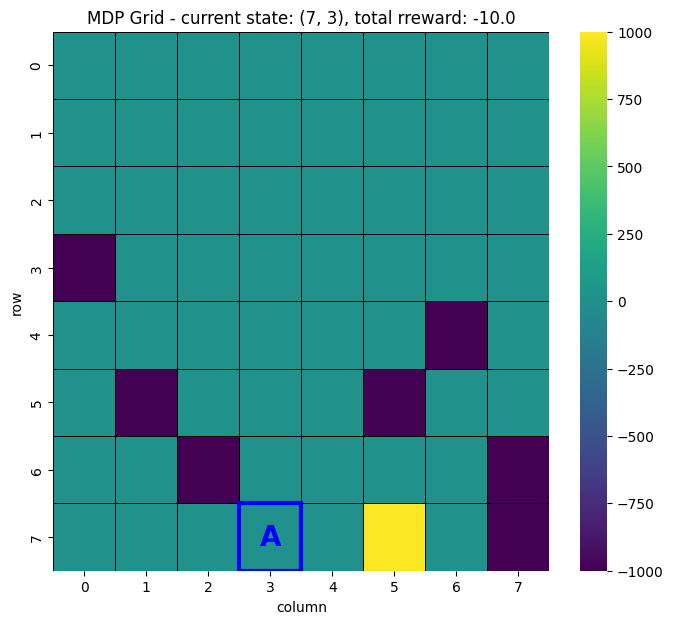


Agent is at: (7, 3)
Total reward accumulated: -10.0
Enter action (up, down, left, right): up
Moved UP. New state: (6, 3). Reward from this move: 0.0.


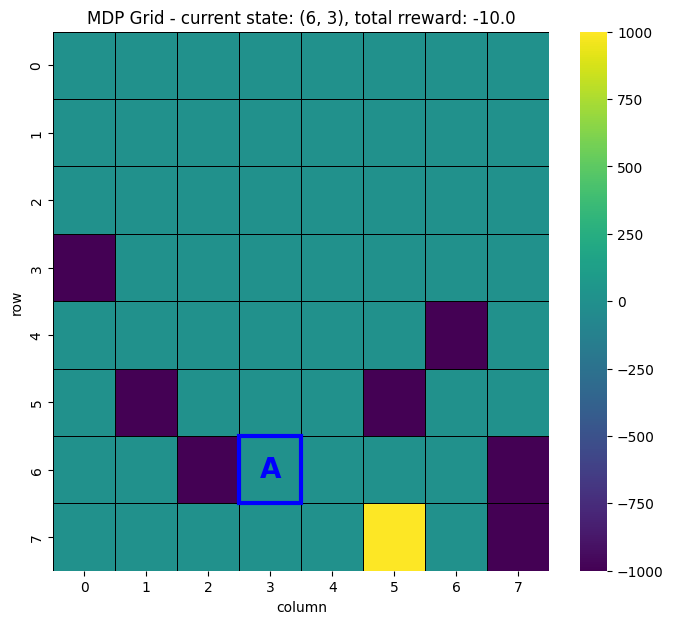


Agent is at: (6, 3)
Total reward accumulated: -10.0
Enter action (up, down, left, right): right
Moved RIGHT. New state: (6, 4). Reward from this move: 0.0.


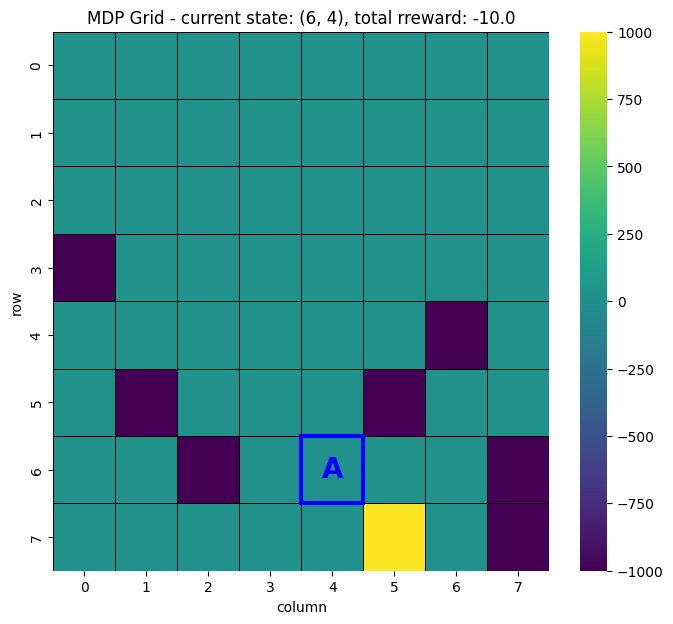


Agent is at: (6, 4)
Total reward accumulated: -10.0
Enter action (up, down, left, right): right
Moved RIGHT. New state: (6, 5). Reward from this move: 0.0.


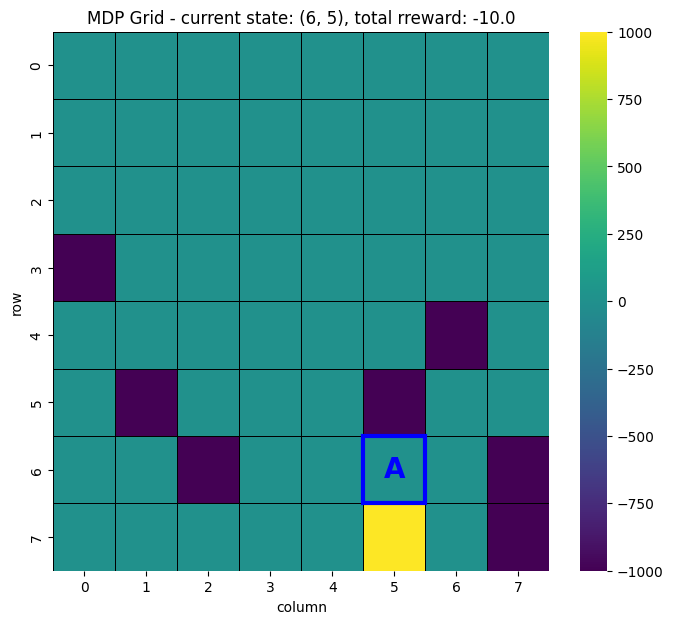


Agent is at: (6, 5)
Total reward accumulated: -10.0
Enter action (up, down, left, right): down
Moved DOWN. New state: (7, 5). Reward from this move: 100.0.


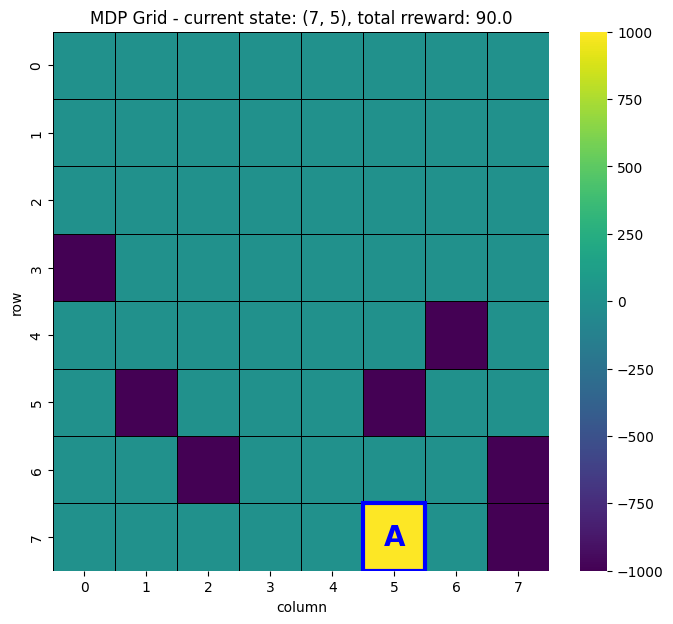


u reached the GOAL at (7, 5)!
final Total Reward: 90.0
path taken: [(0, 0), (0, 0), (1, 0), (1, 1), (1, 2), (2, 2), (3, 2), (4, 2), (4, 3), (5, 3), (5, 4), (6, 4), (7, 4), (7, 3), (6, 3), (6, 4), (6, 5), (7, 5)]


In [6]:
#q2
#making of a interactive MDP model where code asks for used input for the next step.
#MDP-- Markov decision process
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#define world ka grid
rows, cols = 8, 8#world is a 8 by 8 grid[like a chess board]
grid_rewards = np.zeros((rows, cols))

#goal position
goal_position= (7,5)
trap_positions = [(6,2) , (5,1) , (3,0) , (4,6) , (5,5) , (6,7) , (7,7)]
### IMP--- dont make trap and goal position same.
#for checking this doesntt hapen
if goal_position in trap_positions:
    print("Error: Goal and trap positions cannot be the same.")
    exit()

grid_rewards[goal_position] = 100 #award
for r, c in trap_positions:
    grid_rewards[r, c] = -200 #big penulty at traps

#now we implement the MDP algorithm with user input at step
#possible actions
actions = ['up', 'down', 'left', 'right']

#function to determine next state and reward
def get_next_state_and_reward(current_row, current_col, action):
    next_row, next_col = current_row, current_col
    reward = -1 #default penalty for hitting a wall or staying in place

    if action == 'up':
        next_row -= 1
    elif action == 'down':
        next_row += 1
    elif action == 'left':
        next_col -= 1
    elif action == 'right':
        next_col += 1

    #boundary check:if outside grid, stay in current state and apply penalty
    if not (0 <= next_row < rows and 0 <= next_col < cols):
        next_row, next_col = current_row, current_col # Stay in current state
        reward = -10 # Small penalty for invalid move
    else:
        # Valid move, get reward from grid_rewards
        reward = grid_rewards[next_row, next_col]

    return (next_row, next_col), reward

current_state = (0, 0) #starting position
total_reward = 0#intitially no reward
path = [current_state]

#function to visualize the grid
def plot_grid(current_state, goal, traps, rewards, rows, cols):
    grid_display = np.copy(rewards)

    #mark goal,traps for display purposes
    for r, c in traps:
        grid_display[r, c] = -1000 # Represent traps with a unique low value
    grid_display[goal[0], goal[1]] = 1000 # Represent goal with a unique high value

    # Mark current agent position
    agent_grid = np.zeros((rows, cols))
    agent_grid[current_state[0], current_state[1]] = 1 # Mark agent's current spot

    plt.figure(figsize=(8, 7))
    ax = sns.heatmap(
        grid_display,
        cmap='viridis',
        linewidths=.5,
        linecolor='black',
        annot=False,
        cbar=True,
        fmt="f"
    )

    #overlay agent-position with a distinct marker
    ax.add_patch(plt.Rectangle(current_state[::-1], 1, 1, fill=False, edgecolor='blue', lw=3))
    ax.text(current_state[1] + 0.5, current_state[0] + 0.5, 'A',
            horizontalalignment='center', verticalalignment='center',
            color='blue', fontsize=20, fontweight='bold')

    plt.title(f'MDP Grid - current state: {current_state}, total rreward: {total_reward}')
    plt.xlabel('column')
    plt.ylabel('row')
    plt.show()

#loop for interaction from user.
#this loop will be such that if agent enters trap it will end. hence while loop or do-while is suited
while current_state != goal_position and current_state not in trap_positions:
    plot_grid(current_state, goal_position, trap_positions, grid_rewards, rows, cols)

    print(f"\nAgent is at: {current_state}")
    print(f"Total reward accumulated: {total_reward}")

    action_input = input("Enter action (up, down, left, right): ").lower()

    # if the entered action is valid
    if action_input in actions:
        new_state, reward = get_next_state_and_reward(current_state[0], current_state[1], action_input)

        # Update state, reward, and path
        current_state = new_state
        total_reward += reward
        path.append(current_state)

        #Print current state, reward, and total reward
        print(f"Moved {action_input.upper()}. New state: {current_state}. Reward from this move: {reward}.")
    else:
        #Invalid action
        print("Invalid action. Please choose from 'up', 'down', 'left', 'right'.")

#After the loop terminates, print final message
plot_grid(current_state, goal_position, trap_positions, grid_rewards, rows, cols)
if current_state == goal_position:
    print(f"\nu reached the GOAL at {goal_position}!")
elif current_state in trap_positions:
    print(f"\nu fell into a TRAP at {current_state}!")
print(f"final Total Reward: {total_reward}")
print("path taken:", path)

POMDP components initialized:
initial belief state (uniform):
[[0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625]
 [0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625]
 [0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625]
 [0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625]
 [0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625]
 [0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625]
 [0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625]
 [0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625 0.015625]]
POMDP interactive loop setup complete.starting simulation


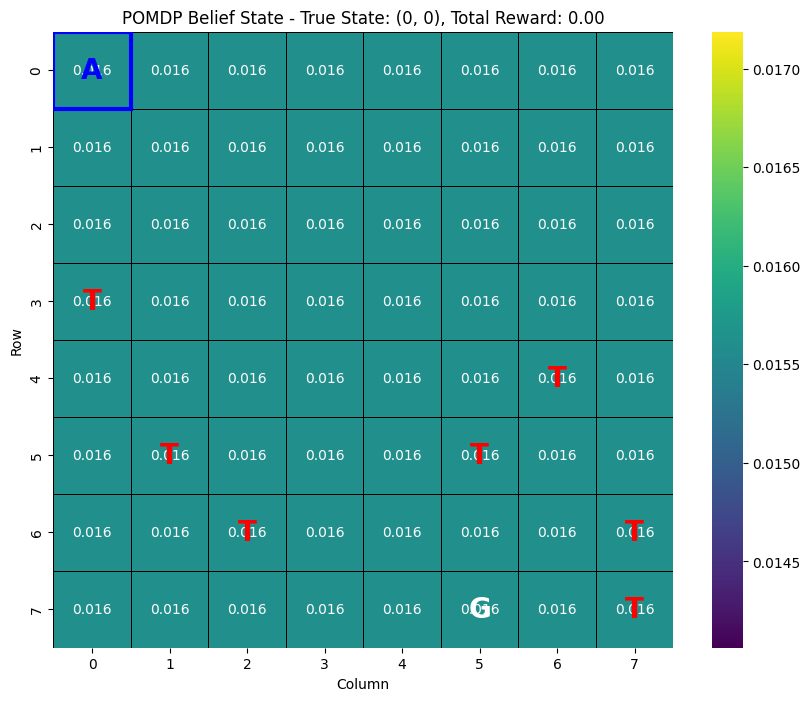


 agent's True Position (for user): (0, 0)
total reward accumulated: 0.00


In [ ]:
#q3 now instead of MDP we have to repeat it using POMDP
#i.e. robot doesnt know its position, only user know.
#hence we use belief state for the robot. logik written in comments
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#define world ka grid
rows, cols = 8, 8#world is a 8 by 8 grid[like a chess board]
grid_rewards = np.zeros((rows, cols))

#goal position
goal_position= (7,5)
trap_positions = [(6,2) , (5,1) , (3,0) , (4,6) , (5,5) , (6,7) , (7,7)]
### IMP--- dont make trap and goal position same.
#for checking this doesntt hapen
if goal_position in trap_positions:
    print("Error: Goal and trap positions cannot be the same.")
    exit()

#function to determine next state and reward
def get_next_state_and_reward(current_row, current_col, action):
    next_row, next_col = current_row, current_col
    reward = -1 #default penalty for hitting a wall or staying in place

    if action == 'up':
        next_row -= 1
    elif action == 'down':
        next_row += 1
    elif action == 'left':
        next_col -= 1
    elif action == 'right':
        next_col += 1

    #boundary check:if outside grid, stay in current state and apply penalty
    if not (0 <= next_row < rows and 0 <= next_col < cols):
        next_row, next_col = current_row, current_col # Stay in current state
        reward = -10 # Small penalty for invalid move
    else:
        # Valid move, get reward from grid_rewards
        reward = grid_rewards[next_row, next_col]

    return (next_row, next_col), reward

#now we have to code the POMDP
# Step 1: Initialize POMDP Components
# Initialize a uniform belief distribution over all possible states of the grid.
belief_state = np.full((rows, cols), 1.0 / (rows * cols))

# Define an observation model function
def generate_observation(state, goal, traps):
    if state == goal:
        return 'goal'
    elif state in traps:
        return 'trap'
    else:
        return 'normal' # Default observation for other states

print("POMDP components initialized:")
print("initial belief state (uniform):")
print(belief_state)

# Assuming rows, cols, goal_position, trap_positions are defined from previous cells
# and get_next_state_and_reward, generate_observation, update_belief functions are defined.

# Ensure grid_rewards is correctly populated, as it was in the initial problem description
# but not explicitly set in the last executed cell (c3a03edf). This ensures
# get_next_state_and_reward functions correctly.
# Re-define grid_rewards if not already defined or correctly populated in the current kernel state
if 'grid_rewards' not in globals() or np.sum(grid_rewards) == 0: # Basic check if grid_rewards is empty or not set
    grid_rewards = np.zeros((rows, cols))
    grid_rewards[goal_position] = 100 #award
    for r, c in trap_positions:
        grid_rewards[r, c] = -200 #big penulty at traps

# Step 1: Initialize true_state, total_reward, and true_path
true_state = (0, 0) # Agent's actual position, unknown to the agent itself
total_reward = 0
true_path = [true_state]

# Step 2: Define actions
actions = ['up', 'down', 'left', 'right']

# Step 3: Create a plotting function for belief state
def plot_pomdp_grid(belief_state, true_state, goal, traps, rewards, rows, cols):
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(
        belief_state,
        cmap='viridis', # A good colormap for probability distributions
        linewidths=.5,
        linecolor='black',
        annot=True, # Show probabilities
        fmt=".3f", # Format annotation to 3 decimal places
        cbar=True
    )

    # Mark goal position with a star
    ax.text(goal[1] + 0.5, goal[0] + 0.5, 'G',
            horizontalalignment='center', verticalalignment='center',
            color='white', fontsize=20, fontweight='bold')

    # Mark trap positions with 'T'
    for r, c in traps:
        ax.text(c + 0.5, r + 0.5, 'T',
                horizontalalignment='center', verticalalignment='center',
                color='red', fontsize=20, fontweight='bold')

    # Mark true_state with a distinct border or 'A' for Agent's actual position (for user's reference)
    ax.add_patch(plt.Rectangle(true_state[::-1], 1, 1, fill=False, edgecolor='blue', lw=3))
    ax.text(true_state[1] + 0.5, true_state[0] + 0.5, 'A',
            horizontalalignment='center', verticalalignment='center',
            color='blue', fontsize=20, fontweight='bold')

    plt.title(f'POMDP Belief State - True State: {true_state}, Total Reward: {total_reward:.2f}')
    plt.xlabel('Column')
    plt.ylabel('Row')
    plt.show()


def update_belief(belief, action, observation):
    #initialize predicted_belief (P(s' | a, s_prev))
    predicted_belief = np.zeros_like(belief, dtype=float)#keep this float for decimal values. double will also work

    #iterate through all possible previous states (s_prev)
    for r_prev in range(rows):
        for c_prev in range(cols):
            if belief[r_prev, c_prev] > 0:
                # Determine the next state (s_prime) given the action
                # The get_next_state_and_reward function returns (next_state, reward)
                next_state_tuple, _ = get_next_state_and_reward(r_prev, c_prev, action)
                next_r, next_c = next_state_tuple

                # Accumulate probability for predicted_belief
                # P(s') = sum_s_prev [P(s' | a, s_prev) * P(s_prev)]
                # In our deterministic world, P(s' | a, s_prev) is 1 for the determined next state
                # and 0 otherwise, so we just add the belief of s_prev to the s_prime cell.
                predicted_belief[next_r, next_c] += belief[r_prev, c_prev]

    # Initialize updated_belief (P(s' | o, a))
    updated_belief = np.zeros_like(belief, dtype=float)
    normalizer = 0.0

    # Incorporate the observation using Bayes' theorem--- P(s' | o, a) = P(o | s') * P(s' | a) / P(o | a)
    for r_prime in range(rows):
        for c_prime in range(cols):
            # Get the expected observation from this potential next state
            expected_observation = generate_observation((r_prime, c_prime), goal_position, trap_positions)

            # P(o | s') - Likelihood
            # In this deterministic observation model, P(o | s') is 1 if expected_observation == observation
            # and 0 otherwise.
            if expected_observation == observation:
                # P(s' | o, a) is proportional to P(s' | a)
                updated_belief[r_prime, c_prime] = predicted_belief[r_prime, c_prime]
            else:
                updated_belief[r_prime, c_prime] = 0.0

            normalizer += updated_belief[r_prime, c_prime]

    #nrmalize the belief state
    if normalizer > 0:
        updated_belief /= normalizer
    else:#here is the error handling mechanissm
        #Handle case where normalizer is zero (no state matches the observation)
        #This might happen if the observation model or transition model is inconsistent
        #or if the agent enters an impossible state given its belief and action.
        #For now, we can return a uniform belief to signify maximum uncertainty,
        #or return the predicted_belief if we want to ignore the observation
        #(but this violates the POMDP update logic). A uniform belief is more robust.
        print("warning: Normalizer= zero. Returning uniform belief.")
        #print of this statement is very imp warning
        updated_belief = np.full((rows, cols), 1.0 / (rows * cols))

    return updated_belief

#print("The `update_belief` function has been defined.")---- for debugin
print("POMDP interactive loop setup complete.starting simulation")


#start the interactive loop
while true_state != goal_position and true_state not in trap_positions:
    #display current belief state and true state
    plot_pomdp_grid(belief_state, true_state, goal_position, trap_positions, grid_rewards, rows, cols)

    #pprint current total_reward
    print(f"\n agent's True Position (for user): {true_state}")
    print(f"total reward accumulated: {total_reward:.2f}")

    #prompt user for an action
    action_input = input("enter action(up, down, left, right):: ").lower()

    #check if the  the user's action are vallid
    if action_input in actions:
        #use get_next_state_and_reward to calculate the new_true_state and reward
        new_true_state, reward_from_move = get_next_state_and_reward(true_state[0], true_state[1], action_input)

        #update true_state
        true_state = new_true_state

        #add the reward to total_reward
        total_reward += reward_from_move

        #append true_state to true_path
        true_path.append(true_state)

        #ggenerate an observation from the new_true_state
        observation = generate_observation(true_state)

        #update the belief_state using the update_belief function
        belief_state = update_belief(belief_state, action_input, observation)

        # g. Print feedback to the user
        print(f"moved {action_input.upper()}. true State: {true_state}. rewardfrom this move: {reward_from_move:.2f}.")
        print(f"observation received: '{observation}'. belief state updated.")
    else:
        #iff the user's action is invalid, print an error message
        print("invalid action/ invalid inputt. Please choose from 'up', 'down', 'left', 'right'.")

#call the plotting function
plot_pomdp_grid(belief_state, true_state, goal_position, trap_positions, grid_rewards, rows, cols)

#print final messages to end the programm
if true_state == goal_position:
    print(f"\nu reached the GOAL at {goal_position}!")
elif true_state in trap_positions:
    print(f"\nu fell into a TRAP at {true_state}!")
print(f"final_total Reward: {total_reward:.2f}")
print("true path taken:", true_path)